<div style="width: 100%; margin-bottom: 20px;">
    <img src="../assets/banner.png" style="width: 100%; border-radius: 10px; height: 300px; object-fit: cover;">
</div>

# Phase 3 : Modélisation et Comparaison des Modèles
## Projet ML : Prédiction des Tempêtes Géomagnétiques

**Réalisé par :**
- AMEZIANE Oumaima
- ROHAND Douae
- MOHITO Raihana

**Date :** 2025-2026  
**Cours :** Machine Learning – 2ème année Cycle Ingénieurs GI  
**Encadrant :** Pr. Y. EL YOUNOUSSI

---
Ce notebook correspond à la **Phase 3** du projet AURORAS.
Notre cible est d'identifier la meilleure combinaison d'un modèle et d'une stratégie de rééquilibrage de classes.
La métrique de performance principale évaluée est le **Recall** (pour minimiser les faux négatifs, des événements catastrophiques de météo spatiale manqués), mais nous allons aussi garder un œil sur le score **F1**, **Precision** et l'**AUC**.

## Objectifs :
1. Tester 4 modèles différents (Logistic Regression, Decision Tree, Random Forest, XGBoost).
2. Vérifier 3 techniques de gestion du déséquilibre (class_weight, SMOTE, Undersampling) dans des **Pipelines imblearn**.
3. Obtenir un tableau comparatif final et retenir la meilleure combinaison.


## Étape 1 — Imports et chargement des données

Dans cette étape nous importons toutes les bibliothèques nécessaires **en haut du notebook** .
Nous chargeons aussi :
- Le `preprocessor.joblib` créé en Phase 2
- Le jeu `train.csv` **fusionné** avec `validation.csv` pour maximiser les données disponibles lors de la validation croisée.
  Le jeu `test.csv` reste intouché jusqu'au notebook `06_evaluation.ipynb`.


In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

# XGBoost
from xgboost import XGBClassifier

# imblearn — Pipeline OBLIGATOIRE pour éviter le data leakage avec SMOTE/Undersampling
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

pd.set_option('display.max_columns', None)

# ---------------------------------------------------------
# 1. Chargement du preprocessor (Phase 2)
# ---------------------------------------------------------
preprocessor = joblib.load('../models/preprocessor.joblib')
print("Preprocessor chargé avec succès !")

# ---------------------------------------------------------
# 2. Chargement et fusion train + validation
# Le test set (test.csv) reste intouché jusqu'à 06_evaluation.ipynb
# ---------------------------------------------------------
TARGET = 'is_storm'

df_train = pd.read_csv('../data/processed/train.csv')
df_val   = pd.read_csv('../data/processed/validation.csv')
df_all   = pd.concat([df_train, df_val], ignore_index=True)

X_train = df_all.drop(columns=[TARGET])
y_train = df_all[TARGET]

print(f"Taille du jeu d'entraînement fusionné : {X_train.shape}")
print(f"Distribution de la cible :\n{y_train.value_counts(normalize=True).mul(100).round(2)}")


Preprocessor chargé avec succès !
Taille du jeu d'entraînement fusionné : (36725, 24)
Distribution de la cible :
is_storm
0    91.59
1     8.41
Name: proportion, dtype: float64


## Étape 2 — Définir les 4 modèles

On choisit 4 familles d'algorithmes pour leur **diversité algorithmique** :
| Modèle | Type | Avantage clé |
|---|---|---|
| Régression Logistique | Linéaire | Baseline rapide & interprétable |
| Arbre de Décision | Non-linéaire | Très interprétable |
| Random Forest | Ensemble (bagging) | Robuste, peu de tuning |
| XGBoost | Ensemble (boosting) | Souvent le meilleur sur tabulaire |


In [3]:
models = {
    'Logistic_Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision_Tree':       DecisionTreeClassifier(random_state=42),
    'Random_Forest':       RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
}
print(f"{len(models)} modèles définis : {list(models.keys())}")


4 modèles définis : ['Logistic_Regression', 'Decision_Tree', 'Random_Forest', 'XGBoost']


## Étape 3 — Définir les 3 stratégies de rééquilibrage

| Stratégie | Principe | Note |
|---|---|---|
| **Baseline (class_weight)** | Aucune donnée générée/supprimée — on pondère les erreurs | Paramètre interne du modèle |
| **SMOTE** | Création de données synthétiques pour la classe minoritaire | imblearn |
| **Undersampling** | Suppression aléatoire de la classe majoritaire | imblearn |

> **Important :** SMOTE et Undersampling sont appliqués **DANS** le pipeline imblearn, uniquement sur les folds d'entraînement.
> Les folds de validation ne voient jamais de données synthétiques — cela évite le **data leakage**.


In [4]:
smote       = SMOTE(random_state=42)
undersampler = RandomUnderSampler(random_state=42)

strategies = {
    'No_Resampling_ClassWeight': 'class_weight',
    'SMOTE':                      smote,
    'Undersampling':              undersampler,
}
print(f"{len(strategies)} stratégies définies : {list(strategies.keys())}")


3 stratégies définies : ['No_Resampling_ClassWeight', 'SMOTE', 'Undersampling']


## Étape 4 — Construire les 12 pipelines et lancer la validation croisée

**Principe du pipeline imblearn :**
Pour chacun des 5 folds de la StratifiedKFold :
1. `Preprocessor` appliqué sur les **4 folds d'entraînement** seulement.
2. `Resampler` (SMOTE/Undersampling) équilibre **les données d'entraînement** transformées.
3. Le `Modèle` s'entraîne.
4. Le pipeline prédit sur le **fold de validation** ; sans données synthétiques, sans fuite.

En cas d'erreur sur une configuration, elle est enregistrée avec `NaN` et un message explicite est affiché.


In [5]:
results_list = []

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['recall', 'f1', 'precision', 'roc_auc']

# Ratio pour scale_pos_weight de XGBoost (équivalent class_weight)
scale_pos_w = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight XGBoost : {scale_pos_w:.2f}")

print("\n===== Début des entraînements =====")

for model_name, model in models.items():
    for strategy_name, strategy in strategies.items():

        current_model = clone(model)  # clone propre à chaque itération

        # --- Ajustement des poids (stratégie class_weight uniquement) ---
        if strategy_name == 'No_Resampling_ClassWeight':
            if model_name == 'XGBoost':
                current_model.set_params(scale_pos_weight=scale_pos_w)
            elif model_name == 'Random_Forest':
                current_model.set_params(class_weight='balanced_subsample')
            else:
                current_model.set_params(class_weight='balanced')
        else:
            # Avec SMOTE/Undersampling, pas besoin de poids internes
            if model_name == 'XGBoost':
                current_model.set_params(scale_pos_weight=1)
            else:
                current_model.set_params(class_weight=None)

        # --- Construction du pipeline ---
        if strategy_name == 'No_Resampling_ClassWeight':
            pipeline = ImbPipeline([
                ('preprocessor', preprocessor),
                ('clf', current_model)
            ])
        else:
            pipeline = ImbPipeline([
                ('preprocessor', preprocessor),
                ('resampler',    clone(strategy)),
                ('clf',          current_model)
            ])

        print(f"  [{model_name}] + [{strategy_name}] ...", end=' ', flush=True)

        # --- Validation croisée ---
        try:
            cv_results = cross_validate(
                pipeline, X_train, y_train,
                cv=cv, scoring=scoring,
                return_train_score=False, n_jobs=-1
            )
            results_list.append({
                'Model':               model_name,
                'Balancing_Strategy':  strategy_name,
                'Recall_Mean':         np.mean(cv_results['test_recall']),
                'Recall_Std':          np.std(cv_results['test_recall']),
                'F1_Mean':             np.mean(cv_results['test_f1']),
                'F1_Std':              np.std(cv_results['test_f1']),
                'Precision_Mean':      np.mean(cv_results['test_precision']),
                'ROC_AUC_Mean':        np.mean(cv_results['test_roc_auc']),
            })
            print(f"Recall={np.mean(cv_results['test_recall']):.4f}  F1={np.mean(cv_results['test_f1']):.4f}")

        except Exception as e:
            print(f"ERREUR : {e}")
            results_list.append({
                'Model':               model_name,
                'Balancing_Strategy':  strategy_name,
                'Recall_Mean':         np.nan,
                'Recall_Std':          np.nan,
                'F1_Mean':             np.nan,
                'F1_Std':              np.nan,
                'Precision_Mean':      np.nan,
                'ROC_AUC_Mean':        np.nan,
            })

print("\n===== Fin des entraînements =====")


scale_pos_weight XGBoost : 10.89

===== Début des entraînements =====
  [Logistic_Regression] + [No_Resampling_ClassWeight] ... Recall=0.7795  F1=0.3924
  [Logistic_Regression] + [SMOTE] ... Recall=0.7799  F1=0.3937
  [Logistic_Regression] + [Undersampling] ... Recall=0.7792  F1=0.3909
  [Decision_Tree] + [No_Resampling_ClassWeight] ... Recall=0.5792  F1=0.6034
  [Decision_Tree] + [SMOTE] ... Recall=0.6779  F1=0.6099
  [Decision_Tree] + [Undersampling] ... Recall=0.8252  F1=0.4461
  [Random_Forest] + [No_Resampling_ClassWeight] ... Recall=0.4548  F1=0.6115
  [Random_Forest] + [SMOTE] ... Recall=0.7294  F1=0.7518
  [Random_Forest] + [Undersampling] ... Recall=0.9171  F1=0.5257
  [XGBoost] + [No_Resampling_ClassWeight] ... Recall=0.7996  F1=0.6629
  [XGBoost] + [SMOTE] ... Recall=0.6089  F1=0.6606
  [XGBoost] + [Undersampling] ... Recall=0.9013  F1=0.5237

===== Fin des entraînements =====


## Étape 5 — Tableau comparatif des 12 configurations

Le tableau est trié par **Recall décroissant** (métrique principale), puis par F1 en cas d'égalité.
Un graphique en barres complète la vue pour faciliter la lecture en présentation.


,Model,Balancing_Strategy,Recall_Mean,Recall_Std,F1_Mean,F1_Std,Precision_Mean,ROC_AUC_Mean
0,Random_Forest,Undersampling,0.9171,0.0078,0.5257,0.0042,0.3685,0.9549
1,XGBoost,Undersampling,0.9013,0.0140,0.5237,0.0118,0.3692,0.9493
2,Decision_Tree,Undersampling,0.8252,0.0189,0.4461,0.0232,0.3058,0.8262
3,XGBoost,No_Resampling_ClassWeight,0.7996,0.0095,0.6629,0.0120,0.5663,0.9616
4,Logistic_Regression,SMOTE,0.7799,0.0120,0.3937,0.0041,0.2633,0.8679
5,Logistic_Regression,No_Resampling_ClassWeight,0.7795,0.0156,0.3924,0.0033,0.2622,0.8685
6,Logistic_Regression,Undersampling,0.7792,0.0130,0.3909,0.0046,0.2609,0.8680
7,Random_Forest,SMOTE,0.7294,0.0147,0.7518,0.0160,0.7757,0.9740
8,Decision_Tree,SMOTE,0.6779,0.0205,0.6099,0.0144,0.5545,0.8139
9,XGBoost,SMOTE,0.6089,0.0085,0.6606,0.0097,0.7221,0.9557


Résultats sauvegardés dans '../data/processed/modeling_results.csv'


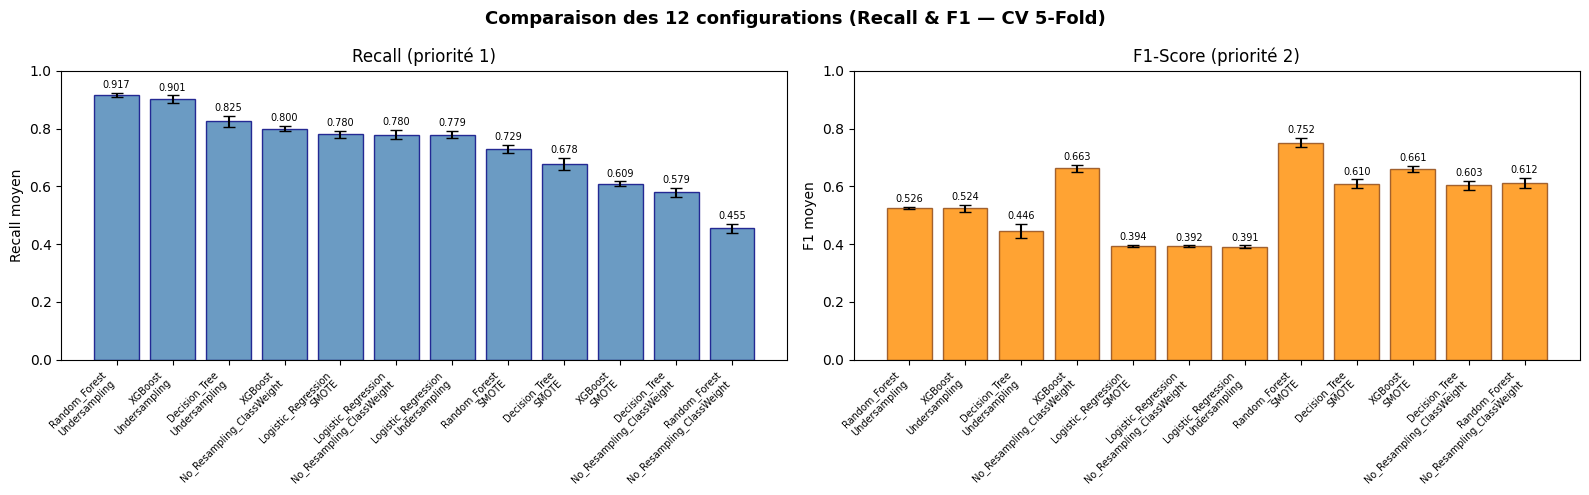

Graphique sauvegardé dans '../data/processed/modeling_comparison.png'


In [6]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(
    by=['Recall_Mean', 'F1_Mean'], ascending=[False, False]
).reset_index(drop=True)

# ---- Affichage tableau ----
display(results_df.round(4))

# ---- Sauvegarde des résultats ----
results_df.to_csv('../data/processed/modeling_results.csv', index=False)
print("Résultats sauvegardés dans '../data/processed/modeling_results.csv'")

# ---- Graphique en barres ----
labels = results_df['Model'] + '\n' + results_df['Balancing_Strategy']
x = range(len(results_df))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Comparaison des 12 configurations (Recall & F1 — CV 5-Fold)', fontsize=13, fontweight='bold')

# Recall
bars = axes[0].bar(x, results_df['Recall_Mean'], yerr=results_df['Recall_Std'],
                   capsize=4, color='steelblue', alpha=0.8, edgecolor='navy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
axes[0].set_title('Recall (priorité 1)')
axes[0].set_ylabel('Recall moyen')
axes[0].set_ylim(0, 1)
axes[0].bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

# F1
bars2 = axes[1].bar(x, results_df['F1_Mean'], yerr=results_df['F1_Std'],
                    capsize=4, color='darkorange', alpha=0.8, edgecolor='saddlebrown')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
axes[1].set_title('F1-Score (priorité 2)')
axes[1].set_ylabel('F1 moyen')
axes[1].set_ylim(0, 1)
axes[1].bar_label(bars2, fmt='%.3f', fontsize=7, padding=2)

plt.tight_layout()
plt.savefig('../data/processed/modeling_comparison.png', bbox_inches='tight', dpi=120)
plt.show()
print("Graphique sauvegardé dans '../data/processed/modeling_comparison.png'")


## Étape 6 — Identifier la meilleure combinaison

La configuration au sommet du tableau trié est la gagnante.
C'est cette paire **Modèle × Stratégie** qui servira de point de départ pour le tuning des hyperparamètres (`05_tuning.ipynb`).


In [7]:
best = results_df.iloc[0]

print("=" * 55)
print("  MEILLEURE COMBINAISON")
print("=" * 55)
print(f"  Modèle              : {best['Model']}")
print(f"  Rééquilibrage       : {best['Balancing_Strategy']}")
print(f"  Recall moyen        : {best['Recall_Mean']:.4f} ± {best['Recall_Std']:.4f}")
print(f"  F1 moyen            : {best['F1_Mean']:.4f} ± {best['F1_Std']:.4f}")
print(f"  Precision moyenne   : {best['Precision_Mean']:.4f}")
print(f"  ROC-AUC moyen       : {best['ROC_AUC_Mean']:.4f}")
print("=" * 55)
print("➜  Ce duo sera optimisé dans 05_tuning.ipynb")


  MEILLEURE COMBINAISON
  Modèle              : Random_Forest
  Rééquilibrage       : Undersampling
  Recall moyen        : 0.9171 ± 0.0078
  F1 moyen            : 0.5257 ± 0.0042
  Precision moyenne   : 0.3685
  ROC-AUC moyen       : 0.9549
➜  Ce duo sera optimisé dans 05_tuning.ipynb


## Conclusion de cette étape de la Phase 3

- Le pipeline `imblearn` garantit l'absence de data leakage : SMOTE et Undersampling ne voient jamais le fold de validation.
- Le tri par **Recall décroissant** est cohérent avec l'objectif métier : minimiser les tempêtes non détectées (faux négatifs).
- Les résultats sont sauvegardés pour ne pas perdre des heures de calcul en cas de re-exécution.
